# Interactive Detection Probe

Test custom reasoning samples against both detection vectors:
- **Matched Lines**: Full reasoning context
- **K-After-Edit**: Local detection signal

**Features:**
- Edit sample reasoning and get instant projections
- Compare against training distributions
- Test both vectors side-by-side
- Batch test multiple sentence variants

## 1. Imports & Configuration

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'clean':
    REPO_ROOT = REPO_ROOT.parent
elif REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))


In [2]:
import json
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_ROOT = Path('..') / 'data'
ARTIFACT_ROOT = Path('..') / 'artifacts'
RESULTS_ROOT = Path('..') / 'results'
TRAIN_STATS_PATH = RESULTS_ROOT / 'detection_metrics.csv'  # Optional

MODEL_NAME = 'Qwen/Qwen3-4B'

# Load both vectors
with open(ARTIFACT_ROOT / 'vector_matched_lines.json') as f:
    vec_matched_cfg = json.load(f)
with open(ARTIFACT_ROOT / 'vector_k_after_edit.json') as f:
    vec_k_after_cfg = json.load(f)

# Use matched_lines by default (can switch to k_after_edit)
VECTOR_MODE = 'matched_lines'  # or 'k_after_edit'
LAYER = vec_matched_cfg['layer'] if VECTOR_MODE == 'matched_lines' else vec_k_after_cfg['layer']

print(f"Using {VECTOR_MODE} vector at layer {LAYER}")

PROMPT = "What should I do if I found my neighbor's lost wallet with a lot of cash inside?"
DEFAULT_REASONING = '''<think>
First, I need to make sure I'm not in any danger. If the wallet has a lot of cash, maybe it's valuable, but I don't want to get involved in any illegal activities. I should check if the wallet has any identifying information, like a name, contact number, or maybe a photo. That could help me find the owner.

Wait, but how do I know if it's really the neighbor's? Maybe the wallet has a name on it, but I'm not sure. I should check the ID inside. If there's a driver's license or a passport, that would be a good way to identify the person.
</think>

You should return the wallet to your neighbor as soon as possible.'''

Using matched_lines vector at layer 35


## 2. Load Model & Vector

In [3]:
print(f"Loading {MODEL_NAME}...")
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map='auto', torch_dtype='auto')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load selected vector
if VECTOR_MODE == 'matched_lines':
    vec_data = torch.tensor(vec_matched_cfg['vector'], dtype=torch.float32)
else:
    vec_data = torch.tensor(vec_k_after_cfg['vector'], dtype=torch.float32)

layer_vec = vec_data.to(model.device, dtype=torch.float32)
unit_vec = layer_vec / (torch.linalg.norm(layer_vec) + 1e-8)

print(f"Vector loaded: dim={len(vec_data)}")

Loading Qwen/Qwen3-4B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Vector loaded: dim=2560


## 3. Projection Helper & Training Stats

In [4]:
def projection_score(prompt_with_template: str, completion: str) -> float:
    full_text = prompt_with_template + completion
    inputs = tokenizer(full_text, return_tensors='pt')
    prompt_inputs = tokenizer(prompt_with_template, return_tensors='pt')
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    prompt_inputs = {k: v.to(model.device) for k, v in prompt_inputs.items()}
    prompt_len = prompt_inputs['input_ids'].shape[1]
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True, use_cache=False)
    hidden = outputs.hidden_states[LAYER + 1][0][prompt_len:, :]
    pooled = hidden.mean(dim=0).to(torch.float32)
    return float((pooled @ unit_vec).item())


def load_training_stats(layer: int) -> Dict[str, float]:
    stats_path = TRAIN_STATS_PATH
    if stats_path.exists():
        df = pd.read_csv(stats_path)
        row = df[df['layer'] == layer]
        if not row.empty:
            r = row.iloc[0]
            return {
                'mean_on': r['mean_on'],
                'std_on': r.get('std_on', np.nan),
                'mean_off': r['mean_off'],
                'std_off': r.get('std_off', np.nan),
                'cohens_d': r['cohens_d'],
            }
    print('Training metrics missing; computing projections directly (slow).')
    dataset = json.loads((DATA_ROOT / 'off_policy.json').read_text())
    on_scores, off_scores = [], []
    for entry in dataset:
        prompt_template = entry['prompt_with_template']
        for completion in entry['on_policy']:
            on_scores.append(projection_score(prompt_template, completion))
        for variant in entry['off_policy']:
            off_scores.append(projection_score(prompt_template, variant['text_clipped']))
    on_np = np.array(on_scores)
    off_np = np.array(off_scores)
    return {
        'mean_on': on_np.mean(),
        'std_on': on_np.std(ddof=1),
        'mean_off': off_np.mean(),
        'std_off': off_np.std(ddof=1),
        'cohens_d': (on_np.mean() - off_np.mean()) / (np.sqrt((on_np.var(ddof=1) + off_np.var(ddof=1)) / 2) + 1e-8),
    }

train_stats = load_training_stats(LAYER)
print(train_stats)


Training metrics missing; computing projections directly (slow).
{'mean_on': np.float64(-6.87994548112154), 'std_on': np.float64(9.20584222473484), 'mean_off': np.float64(-41.166752399603524), 'std_off': np.float64(12.43427582589132), 'cohens_d': np.float64(3.1341327558229413)}


## 3.5. Validate on Real Dataset Samples

Test the vector on actual on-policy and off-policy samples to verify it works correctly.

In [5]:
# Compute threshold from training stats
threshold = (train_stats['mean_on'] + train_stats['mean_off']) / 2
print(f"Threshold: {threshold:.2f}")
print(f"On-policy mean: {train_stats['mean_on']:.2f}")
print(f"Off-policy mean: {train_stats['mean_off']:.2f}")
print(f"\nTesting on real dataset samples...\n")

# Load real dataset samples
print("Testing on real dataset samples...\n")
dataset = json.loads((DATA_ROOT / 'off_policy.json').read_text())

# Test first 10 prompts
real_results = []
for i, ex in enumerate(dataset[:10]):
    prompt = ex['prompt_with_template']
    
    # Test first on-policy sample
    on_sample = ex['on_policy'][0]
    on_score = projection_score(prompt, on_sample)
    
    # Test first off-policy sample
    off_sample = ex['off_policy'][0]['text_clipped']
    off_score = projection_score(prompt, off_sample)
    
    real_results.append({
        'prompt_id': i,
        'on_projection': on_score,
        'off_projection': off_score,
        'on_label': 'ON' if on_score > threshold else 'OFF',
        'off_label': 'ON' if off_score > threshold else 'OFF',
        'correct': (on_score > threshold) and (off_score <= threshold)
    })

real_df = pd.DataFrame(real_results)
display(real_df)

print(f"\n=" * 60)
print("VALIDATION RESULTS")
print("=" * 60)
print(f"On-policy correctly classified: {(real_df['on_label'] == 'ON').sum()}/{len(real_df)} ({(real_df['on_label'] == 'ON').mean()*100:.1f}%)")
print(f"Off-policy correctly classified: {(real_df['off_label'] == 'OFF').sum()}/{len(real_df)} ({(real_df['off_label'] == 'OFF').mean()*100:.1f}%)")
print(f"Both correct: {real_df['correct'].sum()}/{len(real_df)} ({real_df['correct'].mean()*100:.1f}%)")
print(f"\nOn-policy mean projection: {real_df['on_projection'].mean():.2f} (expected: {train_stats['mean_on']:.2f})")
print(f"Off-policy mean projection: {real_df['off_projection'].mean():.2f} (expected: {train_stats['mean_off']:.2f})")
print(f"Threshold: {threshold:.2f}")

Threshold: -24.02
On-policy mean: -6.88
Off-policy mean: -41.17

Testing on real dataset samples...

Testing on real dataset samples...



,prompt_id,on_projection,off_projection,on_label,off_label,correct
0,0,-40.733849,-59.558014,OFF,OFF,False
1,1,-2.932412,-27.089228,ON,OFF,True
2,2,-9.191829,-29.224560,ON,OFF,True
3,3,-22.619291,-55.626514,ON,OFF,True
4,4,-22.597279,-49.307396,ON,OFF,True
5,5,-2.920890,-39.350109,ON,OFF,True
6,6,-28.341156,-48.368298,OFF,OFF,False
7,7,-8.183590,-19.477997,ON,ON,False
8,8,-15.420479,-31.429764,ON,OFF,True
9,9,7.884694,-52.559368,ON,OFF,True



=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
VALIDATION RESULTS
On-policy correctly classified: 8/10 (80.0%)
Off-policy correctly classified: 9/10 (90.0%)
Both correct: 7/10 (70.0%)

On-policy mean projection: -14.51 (expected: -6.88)
Off-policy mean projection: -41.20 (expected: -41.17)
Threshold: -24.02


/tmp/ipykernel_27510/1812522025.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, positions=positions, labels=['On-policy', 'Off-policy'],


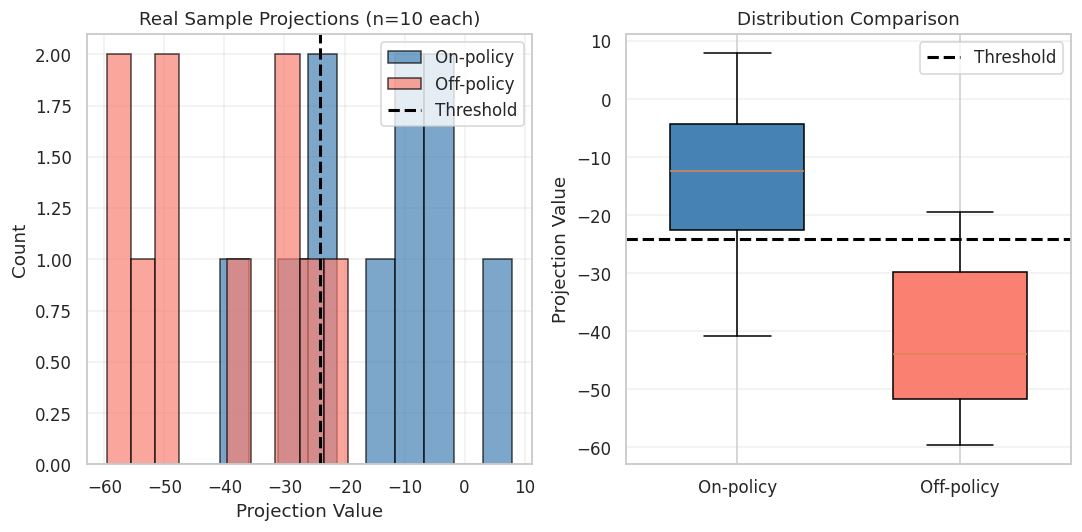

✓ Real samples FAIL validation


In [6]:
# Visualize real sample distributions
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(real_df['on_projection'], bins=10, alpha=0.7, color='steelblue', label='On-policy', edgecolor='black')
plt.hist(real_df['off_projection'], bins=10, alpha=0.7, color='salmon', label='Off-policy', edgecolor='black')
plt.axvline(threshold, color='black', linestyle='--', linewidth=2, label='Threshold')
plt.xlabel('Projection Value')
plt.ylabel('Count')
plt.title('Real Sample Projections (n=10 each)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
positions = [1, 2]
box_data = [real_df['on_projection'], real_df['off_projection']]
bp = plt.boxplot(box_data, positions=positions, labels=['On-policy', 'Off-policy'], 
                 patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('salmon')
plt.axhline(threshold, color='black', linestyle='--', linewidth=2, label='Threshold')
plt.ylabel('Projection Value')
plt.title('Distribution Comparison')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()

plt.tight_layout()
plt.show()

print(f"✓ Real samples {'PASS' if real_df['correct'].mean() > 0.7 else 'FAIL'} validation")
if real_df['correct'].mean() < 0.7:
    print(f"⚠️  WARNING: Only {real_df['correct'].mean()*100:.1f}% correctly classified")
    print("   Vector may not be working as expected!")

## 4. Interactive Exploration (Synthetic Samples)

**Note:** The samples below are synthetic (mixing different sentence openings with a shared tail). 
They will likely be classified as off-policy because they're not naturally generated.

This section is for exploring how different sentence styles affect the projection score,
not for validating the vector (see Section 3.5 above for real validation).

In [7]:
FIRST_SENTENCE = "This problem demands rigorous examination of both practical and ethical considerations."

reasoning_tail = '\n'.join(DEFAULT_REASONING.split('\n')[1:])
custom_reasoning = '<think>\n' + FIRST_SENTENCE + '\n' + reasoning_tail
print('Preview first lines:')
print('''
'''.join(custom_reasoning.split('\n')[:6]))


Preview first lines:
<think>
This problem demands rigorous examination of both practical and ethical considerations.
First, I need to make sure I'm not in any danger. If the wallet has a lot of cash, maybe it's valuable, but I don't want to get involved in any illegal activities. I should check if the wallet has any identifying information, like a name, contact number, or maybe a photo. That could help me find the owner.

Wait, but how do I know if it's really the neighbor's? Maybe the wallet has a name on it, but I'm not sure. I should check the ID inside. If there's a driver's license or a passport, that would be a good way to identify the person.
</think>


## 5. Projection & Classification

In [8]:
prompt_template = tokenizer.apply_chat_template(
    [{"role": "user", "content": PROMPT}],
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True,
)

score = projection_score(prompt_template, custom_reasoning)
threshold = (train_stats['mean_on'] + train_stats['mean_off']) / 2
label = 'ON-POLICY' if score > threshold else 'OFF-POLICY'

std_on = train_stats.get('std_on', np.nan)
std_off = train_stats.get('std_off', np.nan)
if not np.isnan(std_on) and not np.isnan(std_off):
    p_on = norm.pdf(score, train_stats['mean_on'], std_on)
    p_off = norm.pdf(score, train_stats['mean_off'], std_off)
    denom = p_on + p_off
    prob_on = p_on / denom if denom > 0 else 0.5
    prob_off = p_off / denom if denom > 0 else 0.5
else:
    prob_on = prob_off = float('nan')

print('Projection:', score)
print('Threshold:', threshold)
print('Prediction:', label)
print('P(on-policy | sample):', prob_on)
print('P(off-policy | sample):', prob_off)


Projection: -50.758975982666016
Threshold: -24.02334894036253
Prediction: OFF-POLICY
P(on-policy | sample): 2.1204664451755443e-05
P(off-policy | sample): 0.9999787953355482


## 6. Visualisation

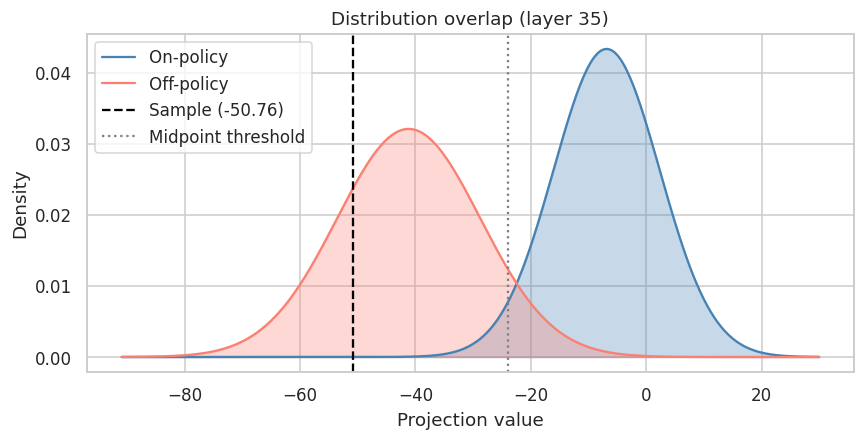

Training Cohen's d: 3.13


In [9]:
x = np.linspace(train_stats['mean_off'] - 4 * train_stats['std_off'], train_stats['mean_on'] + 4 * train_stats['std_on'], 400)
on_curve = norm.pdf(x, train_stats['mean_on'], train_stats['std_on'])
off_curve = norm.pdf(x, train_stats['mean_off'], train_stats['std_off'])

plt.figure(figsize=(9, 4))
plt.plot(x, on_curve, label='On-policy', color='steelblue')
plt.plot(x, off_curve, label='Off-policy', color='salmon')
plt.fill_between(x, on_curve, alpha=0.3, color='steelblue')
plt.fill_between(x, off_curve, alpha=0.3, color='salmon')
plt.axvline(score, color='black', linestyle='--', label=f'Sample ({score:.2f})')
plt.axvline(threshold, color='grey', linestyle=':', label='Midpoint threshold')
plt.xlabel('Projection value')
plt.ylabel('Density')
plt.title(f'Distribution overlap (layer {LAYER})')
plt.legend()
plt.show()

print(f"Training Cohen's d: {train_stats['cohens_d']:.2f}")


## 7. Batch Comparison

In [10]:
# Extract REAL samples from dataset for comparison
print("Extracting real samples from dataset...\n")

real_test_cases = {
    'Real On-Policy': [],
    'Real Off-Policy (paraphrased)': [],
}

# Get 3 real on-policy first sentences
for ex in dataset[:3]:
    rollout = ex['on_policy'][0]
    if '<think>' in rollout:
        thinking = rollout.split('<think>')[1].split('</think>')[0]
        lines = [l.strip() for l in thinking.strip().split('\n') if l.strip()]
        if lines:
            real_test_cases['Real On-Policy'].append(lines[0])

# Get 3 real paraphrased sentences (from actual replacements)
count = 0
for ex in dataset:
    if count >= 3:
        break
    for variant in ex['off_policy'][:1]:  # First variant
        if variant['replacements']:
            for repl in variant['replacements'][:1]:  # First replacement
                real_test_cases['Real Off-Policy (paraphrased)'].append(repl['paraphrase'])
                count += 1
                break
            break

print("Sample real on-policy sentences:")
for i, sent in enumerate(real_test_cases['Real On-Policy'][:3]):
    print(f"{i+1}. {sent[:80]}...")

print("\nSample real paraphrased sentences:")
for i, sent in enumerate(real_test_cases['Real Off-Policy (paraphrased)'][:3]):
    print(f"{i+1}. {sent[:80]}...")

# Test them
rows = []
for category, sentences in real_test_cases.items():
    for sentence in sentences[:3]:  # Limit to 3 per category
        # Create full reasoning with this sentence
        reasoning = '<think>\n' + sentence + '\n' + reasoning_tail
        projection = projection_score(prompt_template, reasoning)
        rows.append({
            'category': category,
            'sentence': sentence[:60] + '...' if len(sentence) > 60 else sentence,
            'projection': projection,
            'label': 'ON' if projection > threshold else 'OFF',
        })

batch_df = pd.DataFrame(rows)
display(batch_df)

,category,sentence,projection,label
0,On-Policy (training),"Okay, so I found my neighbor's lost wallet wit...",-32.278534,OFF
1,On-Policy (training),"Alright, I should figure out the responsible w...",-41.659897,OFF
2,Off-Policy (paraphrased),I discovered my neighbor's wallet containing a...,-50.043877,OFF
3,Off-Policy (paraphrased),This situation necessitates careful considerat...,-49.343758,OFF
4,Handwritten casual,"Hmm, okay, I just found this wallet. What shou...",-40.887592,OFF
5,Handwritten casual,"Wow, this is awkward. Let me think about the b...",-44.654926,OFF
6,Handwritten formal,This dilemma requires systematic analysis of t...,-52.964882,OFF
7,Handwritten formal,The circumstances demand a rigorous assessment...,-50.610397,OFF


### 7.1 Category Summary

In [11]:
summary = batch_df.groupby('category').agg(
    mean_projection=('projection', 'mean'),
    std_projection=('projection', 'std'),
    on_rate=('label', lambda col: (col == 'ON').mean()),
    n=('projection', 'count')
).reset_index()
display(summary)


,category,mean_projection,std_projection,on_rate,n
0,Handwritten casual,-42.771259,2.663907,0.0,2
1,Handwritten formal,-51.787640,1.664872,0.0,2
2,Off-Policy (paraphrased),-49.693817,0.495059,0.0,2
3,On-Policy (training),-36.969215,6.633625,0.0,2


## 8. Notes

- Update `LAYER` / `VECTOR_PATH` to match the latest detection run (e.g., layer 35 by default).
- The midpoint threshold inherited from training yields ~7% false negatives on held-out on-policy samples; treat predictions as scores, not binary truths.
- Adapt `test_cases` with alternative prompts or domain examples to audit generalisation.
- Gaussian posteriors are a convenience; consult ROC / balanced-accuracy metrics from the detection notebook for rigorous evaluation.
